# Coverage-Guided Bandit Campaign Analysis

Analysis of a **1000-mutation campaign** using the Discounted-UCB bandit scheduler.

This notebook visualizes how the bandit scheduler performs: which mutations it favors,
how rewards evolve, whether it learns to exploit productive arms, and what coverage
it achieves.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
from collections import Counter

from a4.standalone.tests.analyze_campaign import parse_terminal, RunRecord

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

TERMINAL_FILE = '/root/.cursor/projects/root-arguzz/terminals/633840.txt'
runs, meta = parse_terminal(TERMINAL_FILE)

pilot = [r for r in runs if r.is_pilot]
bandit = [r for r in runs if not r.is_pilot]
df = pd.DataFrame([vars(r) for r in bandit])
df['idx'] = range(len(df))

SHORT = {
    'COMP_OUT_MOD': 'COMP', 'LOAD_VAL_MOD': 'LOAD', 'STORE_OUT_MOD': 'STORE',
    'PRE_EXEC_REG_MOD': 'PRE_REG', 'INSTR_TYPE_MOD': 'ITYPE',
    'MEM_VAL_MOD': 'MEM', 'INSTR_WORD_MOD_FULL': 'IWORD_F', 'INSTR_WORD_MOD_SUR': 'IWORD_S',
}
df['kind_short'] = df['kind'].map(SHORT)

KIND_ORDER = ['IWORD_S', 'IWORD_F', 'ITYPE', 'PRE_REG', 'COMP', 'MEM', 'LOAD', 'STORE']

print(f'Loaded: {len(pilot)} pilot + {len(bandit)} bandit = {len(runs)} total')
print(f'Calibrated: tau_T={meta.get("tau_T")}, tau_d={meta.get("tau_d")}, '
      f'K_T_rare={meta.get("K_T_rare")}, gamma={meta.get("gamma")}')

Loaded: 50 pilot + 946 bandit = 996 total
Calibrated: tau_T=35.0, tau_d=3.0, K_T_rare=31, gamma=0.9965


---
## 1. Reward Distribution by Mutation Kind

The central question: does the reward function differentiate across mutation kinds?

/tmp/ipykernel_53171/3250117444.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='kind_short', y='reward', order=KIND_ORDER, ax=axes[0],


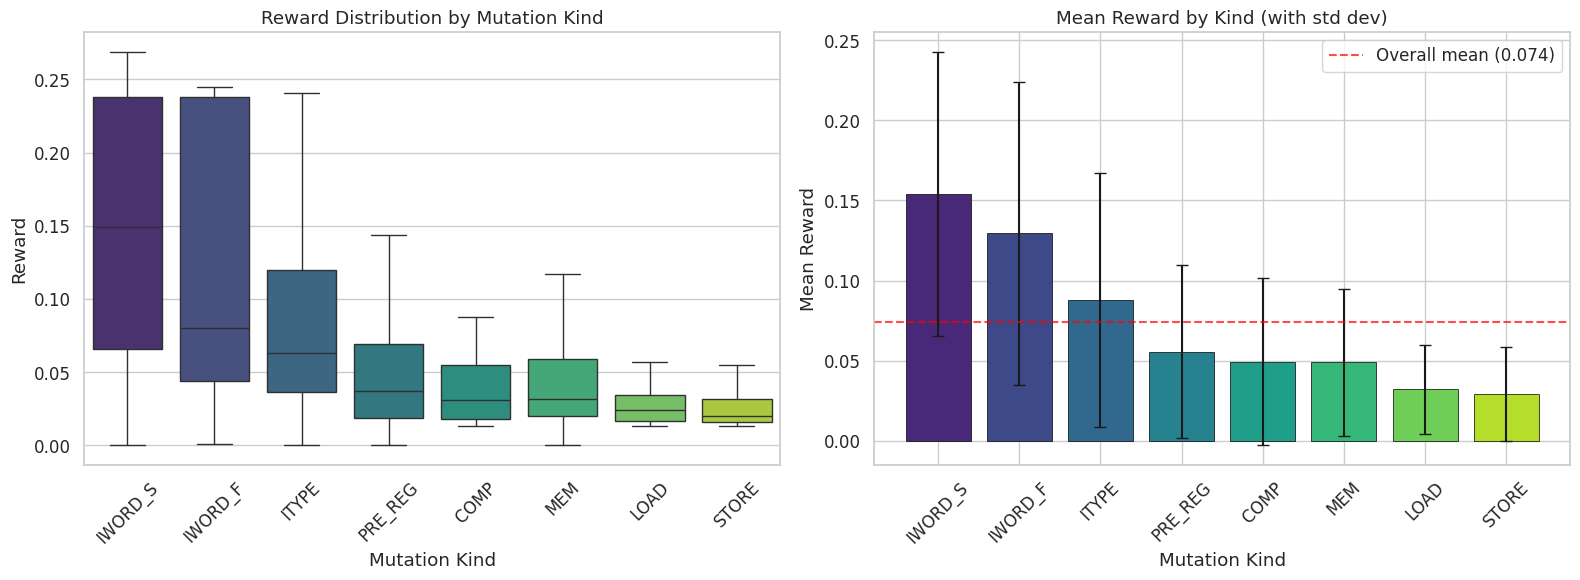


Reward statistics by kind:
             count  mean   std   min   50%   max
kind_short                                      
IWORD_S    120.000 0.154 0.089 0.000 0.149 0.269
IWORD_F    121.000 0.129 0.095 0.001 0.080 0.245
ITYPE      124.000 0.088 0.079 0.000 0.063 0.387
PRE_REG    115.000 0.055 0.054 0.000 0.037 0.238
COMP       117.000 0.049 0.052 0.013 0.031 0.238
MEM        121.000 0.049 0.046 0.000 0.032 0.242
LOAD       115.000 0.032 0.028 0.013 0.024 0.212
STORE      113.000 0.029 0.029 0.013 0.020 0.208


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=df, x='kind_short', y='reward', order=KIND_ORDER, ax=axes[0],
            palette='viridis', showfliers=False)
axes[0].set_title('Reward Distribution by Mutation Kind')
axes[0].set_xlabel('Mutation Kind')
axes[0].set_ylabel('Reward')
axes[0].tick_params(axis='x', rotation=45)

# Mean + stdev bar chart
kind_means = df.groupby('kind_short')['reward'].agg(['mean', 'std']).reindex(KIND_ORDER)
axes[1].bar(kind_means.index, kind_means['mean'], yerr=kind_means['std'],
            capsize=4, color=sns.color_palette('viridis', len(KIND_ORDER)), edgecolor='black', linewidth=0.5)
axes[1].set_title('Mean Reward by Kind (with std dev)')
axes[1].set_xlabel('Mutation Kind')
axes[1].set_ylabel('Mean Reward')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=df['reward'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Overall mean ({df["reward"].mean():.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nReward statistics by kind:')
print(df.groupby('kind_short')['reward'].describe()[['count','mean','std','min','50%','max']]
      .reindex(KIND_ORDER).to_string(float_format='%.3f'))

---
## 2. Reward Component Breakdown

What drives the reward for each mutation kind? The reward is `r = Q * S` where
`S` is a weighted average of T_new, T_rare, F_new, F_rare, Z.

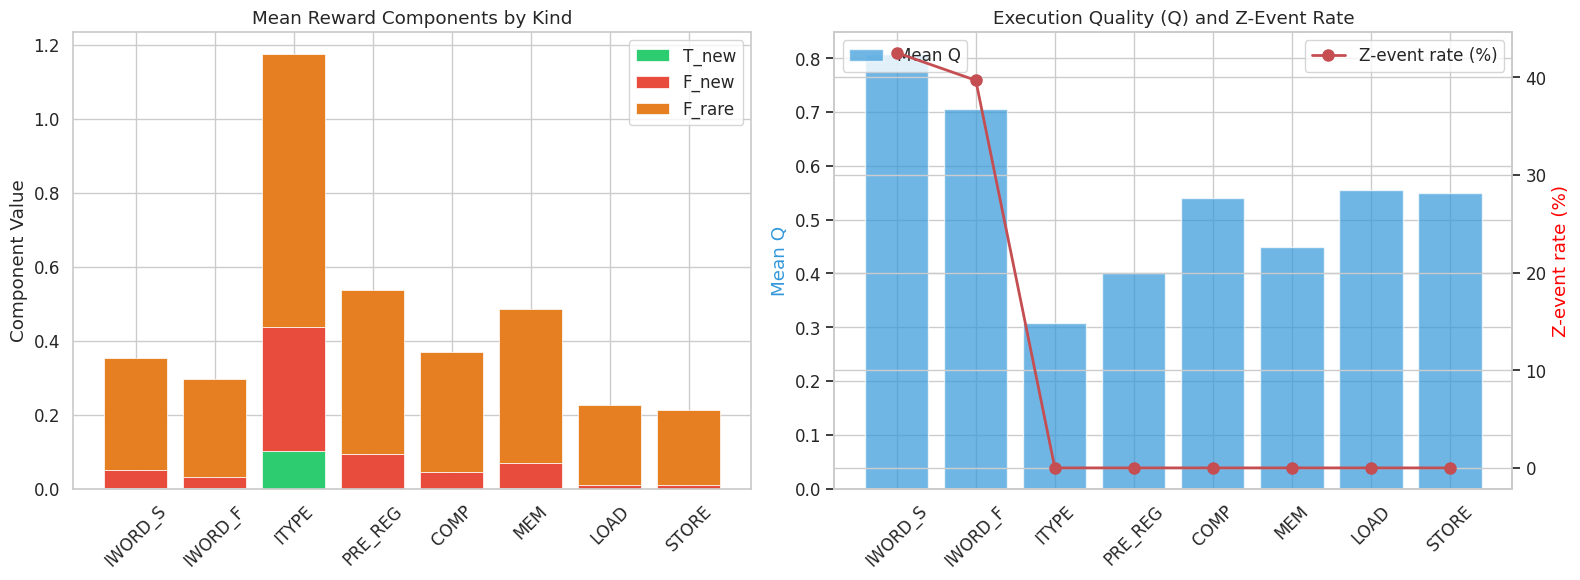

In [4]:
components = df.groupby('kind_short')[['T_new', 'F_new', 'F_rare', 'Q']].mean().reindex(KIND_ORDER)
z_counts = df.groupby('kind_short')['Z'].sum().reindex(KIND_ORDER)
z_rates = (z_counts / df.groupby('kind_short').size().reindex(KIND_ORDER) * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar: mean component values
comp_cols = ['T_new', 'F_new', 'F_rare']
colors = ['#2ecc71', '#e74c3c', '#e67e22']
bottom = np.zeros(len(KIND_ORDER))
for col, color in zip(comp_cols, colors):
    vals = components[col].values
    axes[0].bar(KIND_ORDER, vals, bottom=bottom, label=col, color=color, edgecolor='white', linewidth=0.5)
    bottom += vals
axes[0].set_title('Mean Reward Components by Kind')
axes[0].set_ylabel('Component Value')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Q and Z rate
ax_q = axes[1]
ax_z = ax_q.twinx()
bars = ax_q.bar(KIND_ORDER, components['Q'].values, color='#3498db', alpha=0.7, label='Mean Q')
line = ax_z.plot(KIND_ORDER, z_rates.values, 'ro-', markersize=8, linewidth=2, label='Z-event rate (%)')
ax_q.set_title('Execution Quality (Q) and Z-Event Rate')
ax_q.set_ylabel('Mean Q', color='#3498db')
ax_z.set_ylabel('Z-event rate (%)', color='red')
ax_q.tick_params(axis='x', rotation=45)
ax_q.legend(loc='upper left')
ax_z.legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## 3. Reward Trajectory Over Time

How does the mean reward evolve as the campaign progresses? Novelty saturation
should cause reward to decay, but rarity and Z events should prevent it from
reaching zero.

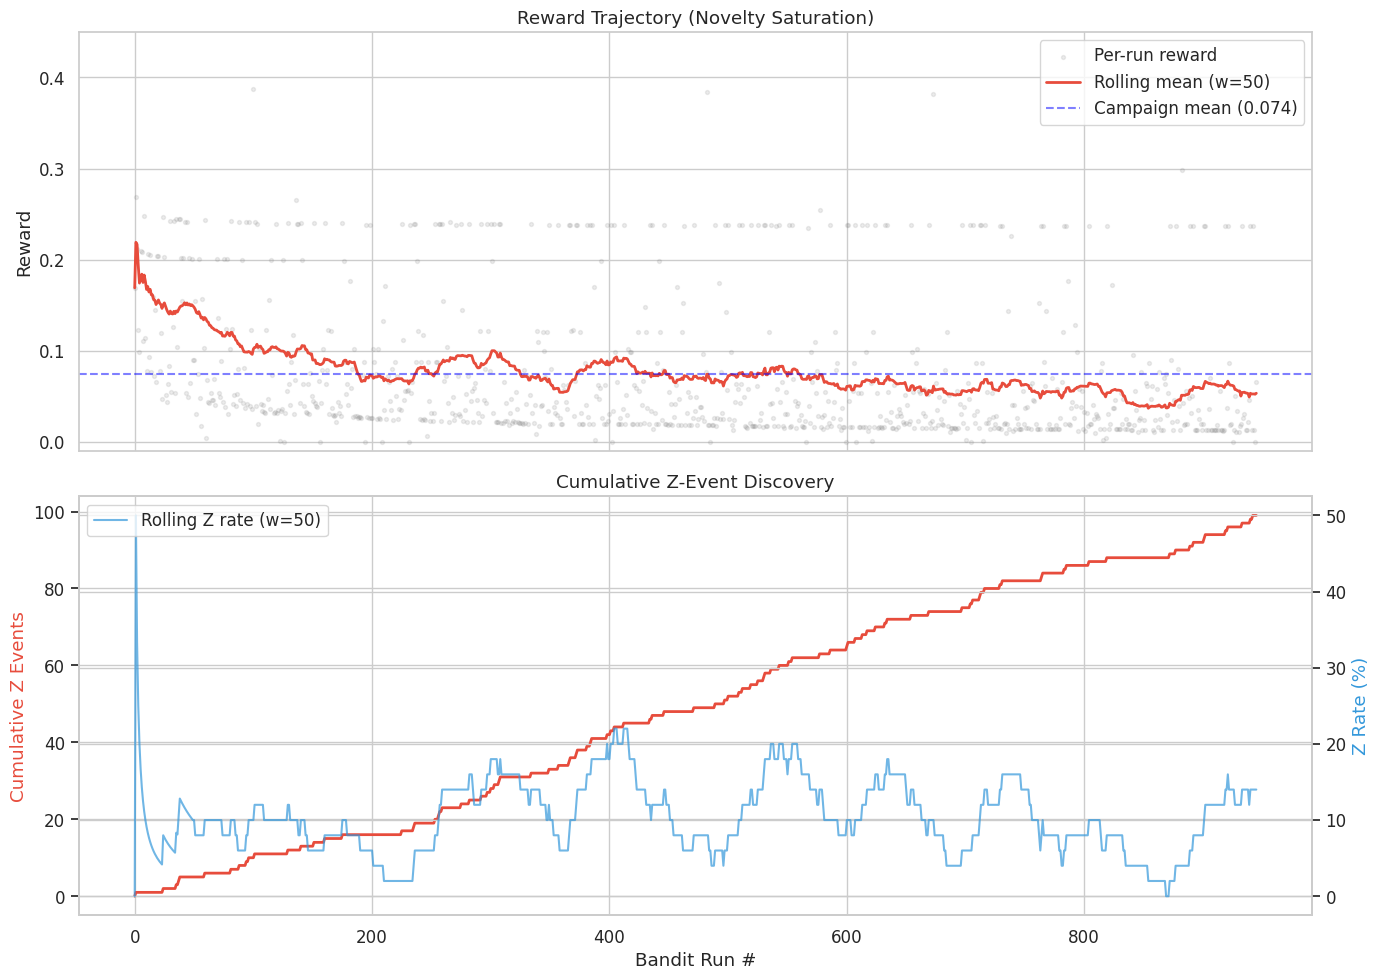

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

window = 50
rolling_reward = df['reward'].rolling(window=window, min_periods=1).mean()

# Top: reward trajectory
axes[0].scatter(df['idx'], df['reward'], alpha=0.15, s=8, c='gray', label='Per-run reward')
axes[0].plot(df['idx'], rolling_reward, color='#e74c3c', linewidth=2, label=f'Rolling mean (w={window})')
axes[0].axhline(y=df['reward'].mean(), color='blue', linestyle='--', alpha=0.5, label=f'Campaign mean ({df["reward"].mean():.3f})')
axes[0].set_ylabel('Reward')
axes[0].set_title('Reward Trajectory (Novelty Saturation)')
axes[0].legend(loc='upper right')
axes[0].set_ylim(-0.01, 0.45)

# Bottom: Z events over time
z_cumsum = df['Z'].cumsum()
axes[1].plot(df['idx'], z_cumsum, color='#e74c3c', linewidth=2)
axes[1].set_ylabel('Cumulative Z Events', color='#e74c3c')
axes[1].set_xlabel('Bandit Run #')
axes[1].set_title('Cumulative Z-Event Discovery')

ax2 = axes[1].twinx()
rolling_z_rate = df['Z'].rolling(window=window, min_periods=1).mean() * 100
ax2.plot(df['idx'], rolling_z_rate, color='#3498db', linewidth=1.5, alpha=0.7, label=f'Rolling Z rate (w={window})')
ax2.set_ylabel('Z Rate (%)', color='#3498db')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## 4. Bandit Learning Curve: Kind Selection Over Time

Is the bandit learning to prefer high-reward kinds? We split the campaign into
10 equal phases and plot the selection frequency per kind.

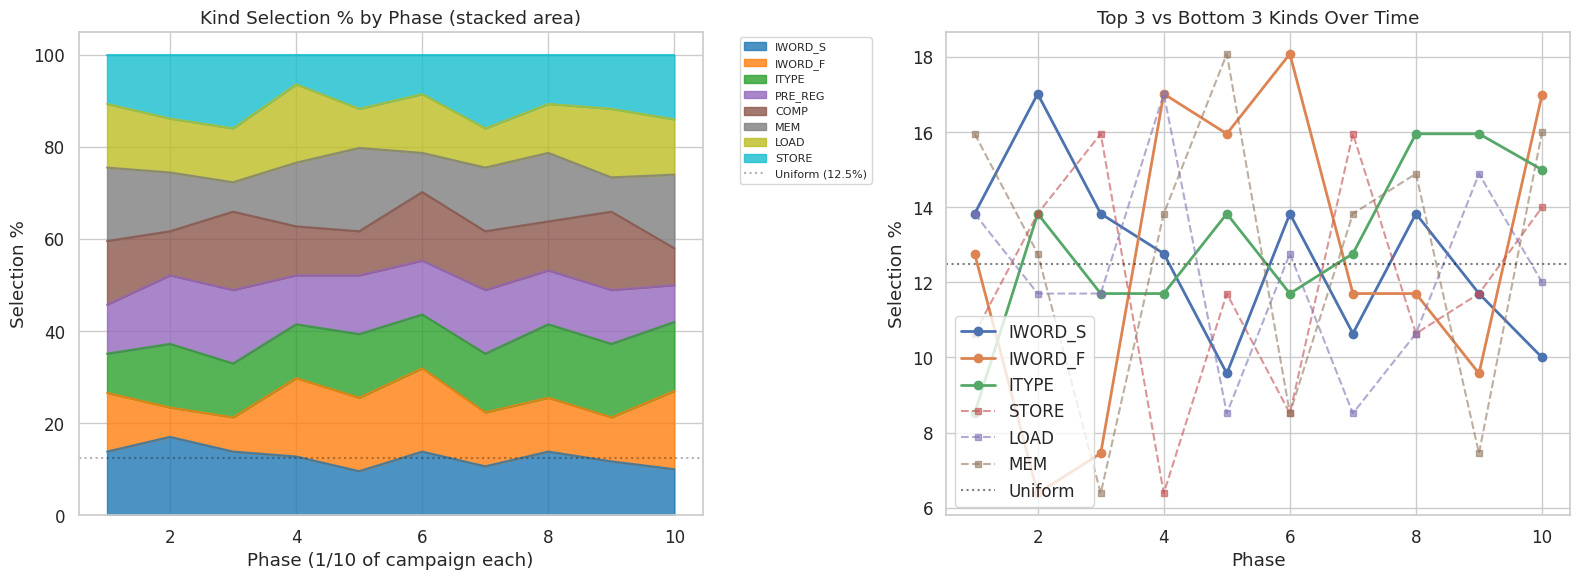

In [6]:
n_phases = 10
phase_size = len(df) // n_phases

phase_data = []
for p in range(n_phases):
    start = p * phase_size
    end = start + phase_size if p < n_phases - 1 else len(df)
    phase_df = df.iloc[start:end]
    counts = phase_df['kind_short'].value_counts()
    total = len(phase_df)
    for kind in KIND_ORDER:
        phase_data.append({'phase': p+1, 'kind': kind, 'pct': counts.get(kind, 0) / total * 100})

phase_df_plot = pd.DataFrame(phase_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked area
pivot = phase_df_plot.pivot(index='phase', columns='kind', values='pct')[KIND_ORDER]
pivot.plot.area(ax=axes[0], stacked=True, alpha=0.8, colormap='tab10')
axes[0].set_title('Kind Selection % by Phase (stacked area)')
axes[0].set_xlabel('Phase (1/10 of campaign each)')
axes[0].set_ylabel('Selection %')
axes[0].axhline(y=12.5, color='black', linestyle=':', alpha=0.3, label='Uniform (12.5%)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Line chart for top 3 kinds
top3 = ['IWORD_S', 'IWORD_F', 'ITYPE']
bottom3 = ['STORE', 'LOAD', 'MEM']
for kind in top3:
    kd = phase_df_plot[phase_df_plot['kind'] == kind]
    axes[1].plot(kd['phase'], kd['pct'], 'o-', linewidth=2, markersize=6, label=kind)
for kind in bottom3:
    kd = phase_df_plot[phase_df_plot['kind'] == kind]
    axes[1].plot(kd['phase'], kd['pct'], 's--', linewidth=1.5, markersize=5, alpha=0.6, label=kind)
axes[1].axhline(y=12.5, color='black', linestyle=':', alpha=0.5, label='Uniform')
axes[1].set_title('Top 3 vs Bottom 3 Kinds Over Time')
axes[1].set_xlabel('Phase')
axes[1].set_ylabel('Selection %')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. Failure Novelty Decay

How quickly does the failure novelty signal (F_new) exhaust? This tells us how
long the bandit has a strong differentiating signal before it must rely on
F_rare and Z.

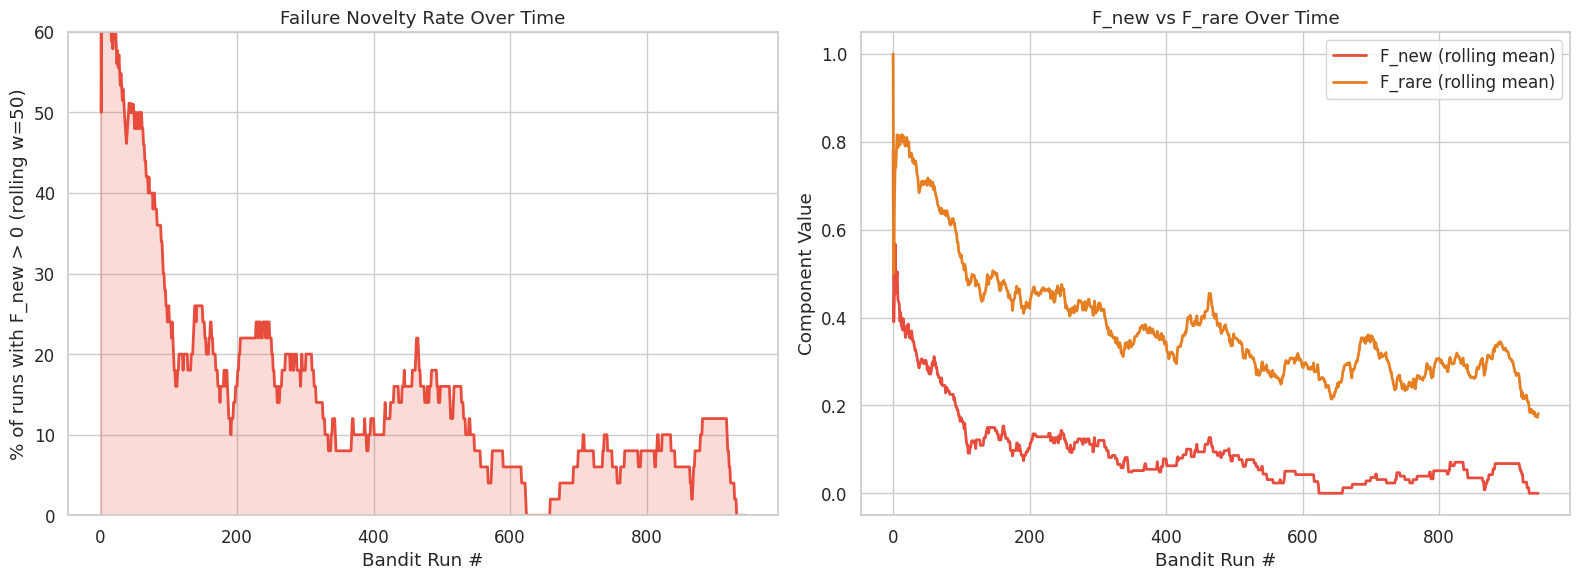

F_new > 0 rate: first 100 = 37.0%, last 100 = 6.0%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F_new rolling rate
f_new_positive = (df['F_new'] > 0).astype(int)
rolling_fnew = f_new_positive.rolling(window=50, min_periods=1).mean() * 100
axes[0].plot(df['idx'], rolling_fnew, color='#e74c3c', linewidth=2)
axes[0].fill_between(df['idx'], 0, rolling_fnew, alpha=0.2, color='#e74c3c')
axes[0].set_title('Failure Novelty Rate Over Time')
axes[0].set_xlabel('Bandit Run #')
axes[0].set_ylabel('% of runs with F_new > 0 (rolling w=50)')
axes[0].set_ylim(0, 60)

# F_rare trajectory
rolling_frare = df['F_rare'].rolling(window=50, min_periods=1).mean()
rolling_fnew_val = df['F_new'].rolling(window=50, min_periods=1).mean()
axes[1].plot(df['idx'], rolling_fnew_val, color='#e74c3c', linewidth=2, label='F_new (rolling mean)')
axes[1].plot(df['idx'], rolling_frare, color='#e67e22', linewidth=2, label='F_rare (rolling mean)')
axes[1].set_title('F_new vs F_rare Over Time')
axes[1].set_xlabel('Bandit Run #')
axes[1].set_ylabel('Component Value')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'F_new > 0 rate: first 100 = {f_new_positive[:100].mean()*100:.1f}%, '
      f'last 100 = {f_new_positive[-100:].mean()*100:.1f}%')

---
## 6. Z-Event Deep Dive

Z events (zero local failures + proof rejected) are the most promising signal
for finding underconstraints. Where do they cluster?

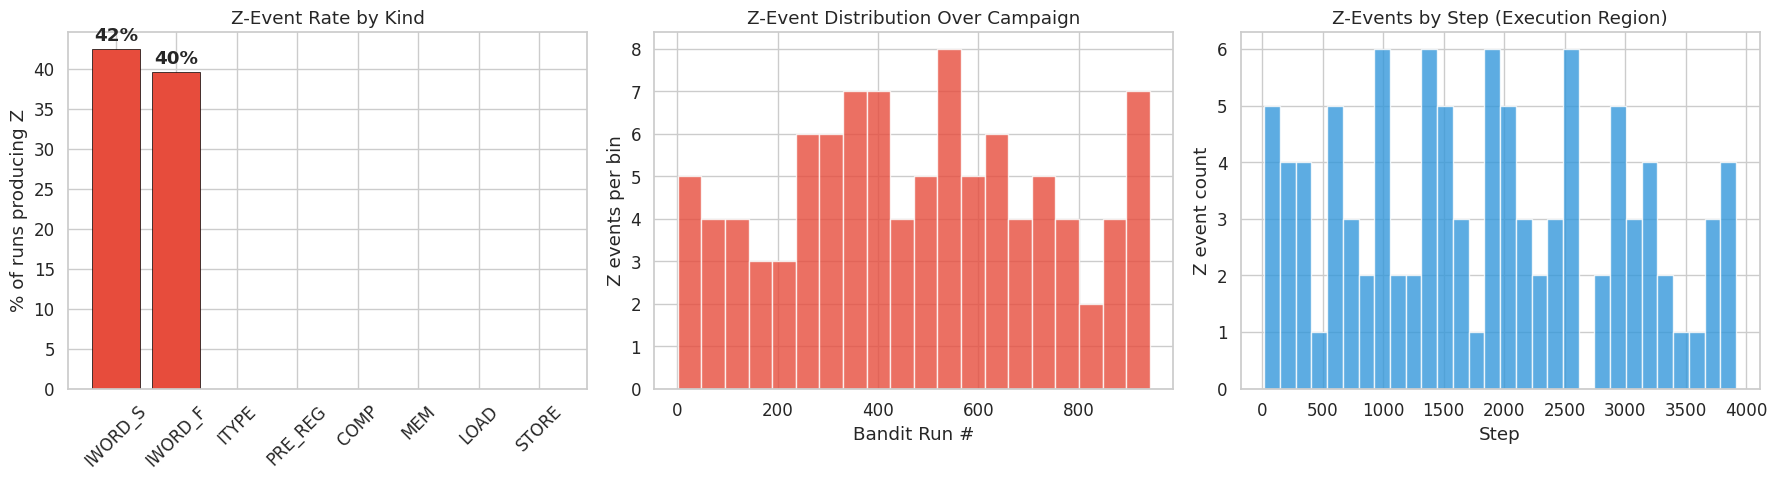


Total Z events: 99 out of 946 bandit runs (10.5%)
Z reward mean: 0.239 vs non-Z: 0.055 (4.4x)


In [8]:
z_df = df[df['Z'] == 1].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Z by kind
z_by_kind = z_df['kind_short'].value_counts().reindex(KIND_ORDER, fill_value=0)
total_by_kind = df['kind_short'].value_counts().reindex(KIND_ORDER, fill_value=0)
z_rate_by_kind = (z_by_kind / total_by_kind * 100).fillna(0)

colors_z = ['#e74c3c' if v > 0 else '#bdc3c7' for v in z_rate_by_kind]
axes[0].bar(KIND_ORDER, z_rate_by_kind, color=colors_z, edgecolor='black', linewidth=0.5)
axes[0].set_title('Z-Event Rate by Kind')
axes[0].set_ylabel('% of runs producing Z')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(z_rate_by_kind):
    if v > 0:
        axes[0].text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold')

# Z events over time (histogram)
axes[1].hist(z_df['idx'], bins=20, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_title('Z-Event Distribution Over Campaign')
axes[1].set_xlabel('Bandit Run #')
axes[1].set_ylabel('Z events per bin')

# Z by step region
axes[2].hist(z_df['step'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[2].set_title('Z-Events by Step (Execution Region)')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Z event count')

plt.tight_layout()
plt.show()

print(f'\nTotal Z events: {len(z_df)} out of {len(df)} bandit runs ({len(z_df)/len(df)*100:.1f}%)')
print(f'Z reward mean: {z_df["reward"].mean():.3f} vs non-Z: {df[df["Z"]==0]["reward"].mean():.3f} '
      f'({z_df["reward"].mean()/df[df["Z"]==0]["reward"].mean():.1f}x)')

---
## 7. Cascade & Quality Analysis

The Q multiplier penalizes runs with many distinct failures (Q_dist) and
cascade repeats (Q_rep). How does this shape the reward landscape?

/tmp/ipykernel_53171/3855465304.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='kind_short', y='Q', order=KIND_ORDER, ax=axes[1],


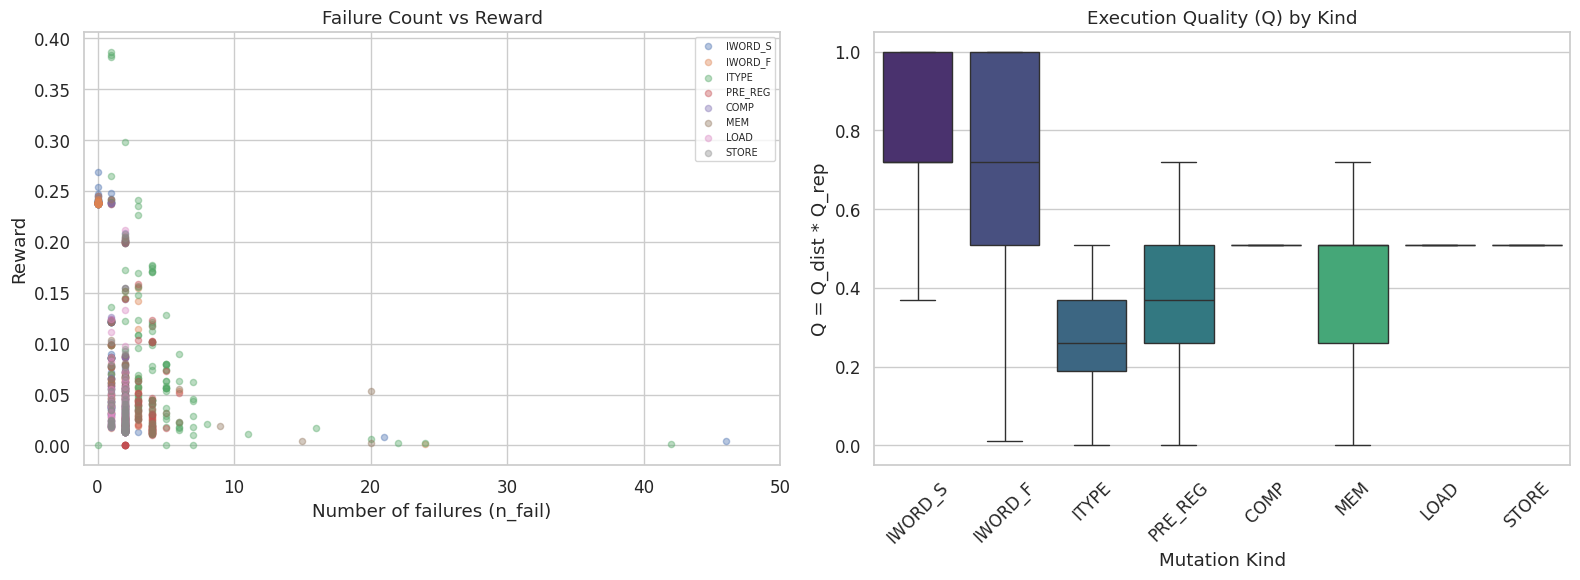

Cascade runs (n_fail > 10): 15
Worst cascade: n_fail=175 (run 980)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: n_fail vs reward colored by kind
for kind in KIND_ORDER:
    kdf = df[df['kind_short'] == kind]
    axes[0].scatter(kdf['n_fail'], kdf['reward'], alpha=0.4, s=20, label=kind)
axes[0].set_title('Failure Count vs Reward')
axes[0].set_xlabel('Number of failures (n_fail)')
axes[0].set_ylabel('Reward')
axes[0].set_xlim(-1, 50)
axes[0].legend(fontsize=7, loc='upper right')

# Q distribution by kind
sns.boxplot(data=df, x='kind_short', y='Q', order=KIND_ORDER, ax=axes[1],
            palette='viridis', showfliers=False)
axes[1].set_title('Execution Quality (Q) by Kind')
axes[1].set_xlabel('Mutation Kind')
axes[1].set_ylabel('Q = Q_dist * Q_rep')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Cascade runs (n_fail > 10): {(df["n_fail"] > 10).sum()}')
print(f'Worst cascade: n_fail={df["n_fail"].max()} (run {df.loc[df["n_fail"].idxmax(), "num"]})')

---
## 8. Touch Coverage Growth

How does the touch bitmap coverage grow over the campaign?

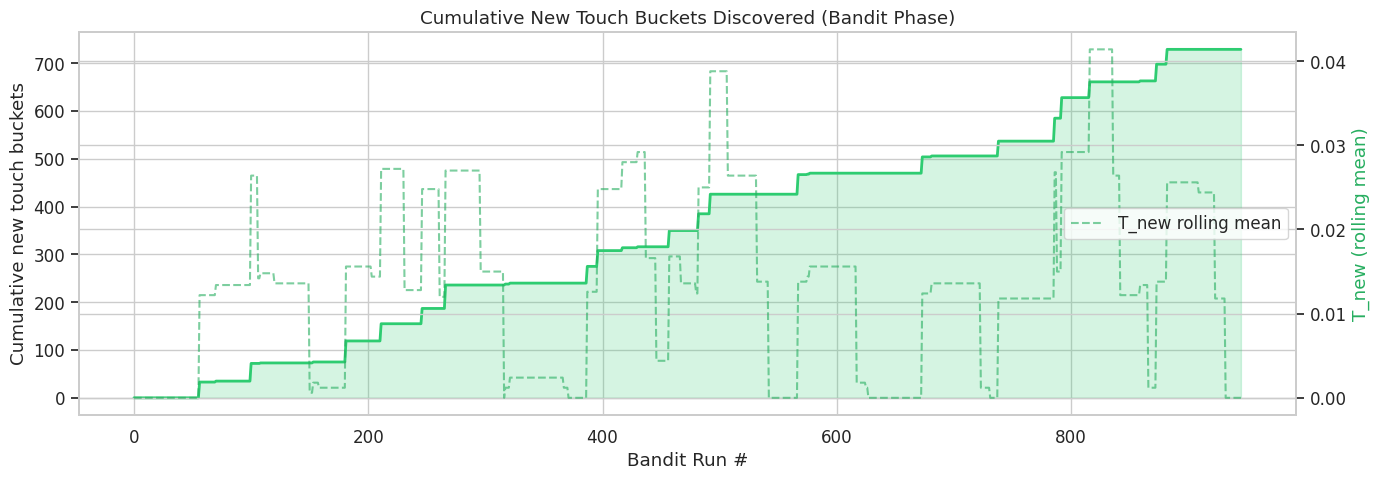

Total new touch from bandit: 729
Baseline: 1599 buckets. After pilot+bandit: 2439 buckets (+840)


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

cum_touch = df['new_touch'].cumsum()
ax.plot(df['idx'], cum_touch, color='#2ecc71', linewidth=2)
ax.fill_between(df['idx'], 0, cum_touch, alpha=0.2, color='#2ecc71')
ax.set_title('Cumulative New Touch Buckets Discovered (Bandit Phase)')
ax.set_xlabel('Bandit Run #')
ax.set_ylabel('Cumulative new touch buckets')

# Annotate with T_new rolling mean
ax2 = ax.twinx()
rolling_tnew = df['T_new'].rolling(window=50, min_periods=1).mean()
ax2.plot(df['idx'], rolling_tnew, color='#27ae60', linewidth=1.5, alpha=0.6, linestyle='--', label='T_new rolling mean')
ax2.set_ylabel('T_new (rolling mean)', color='#27ae60')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

print(f'Total new touch from bandit: {cum_touch.iloc[-1]}')
print(f'Baseline: 1599 buckets. After pilot+bandit: 2439 buckets (+{2439-1599})')

---
## 9. Reward Heatmap: Kind x Step-Bucket

Are there specific (kind, step-region) combinations that consistently produce
high reward? This is what the bandit's arms represent.

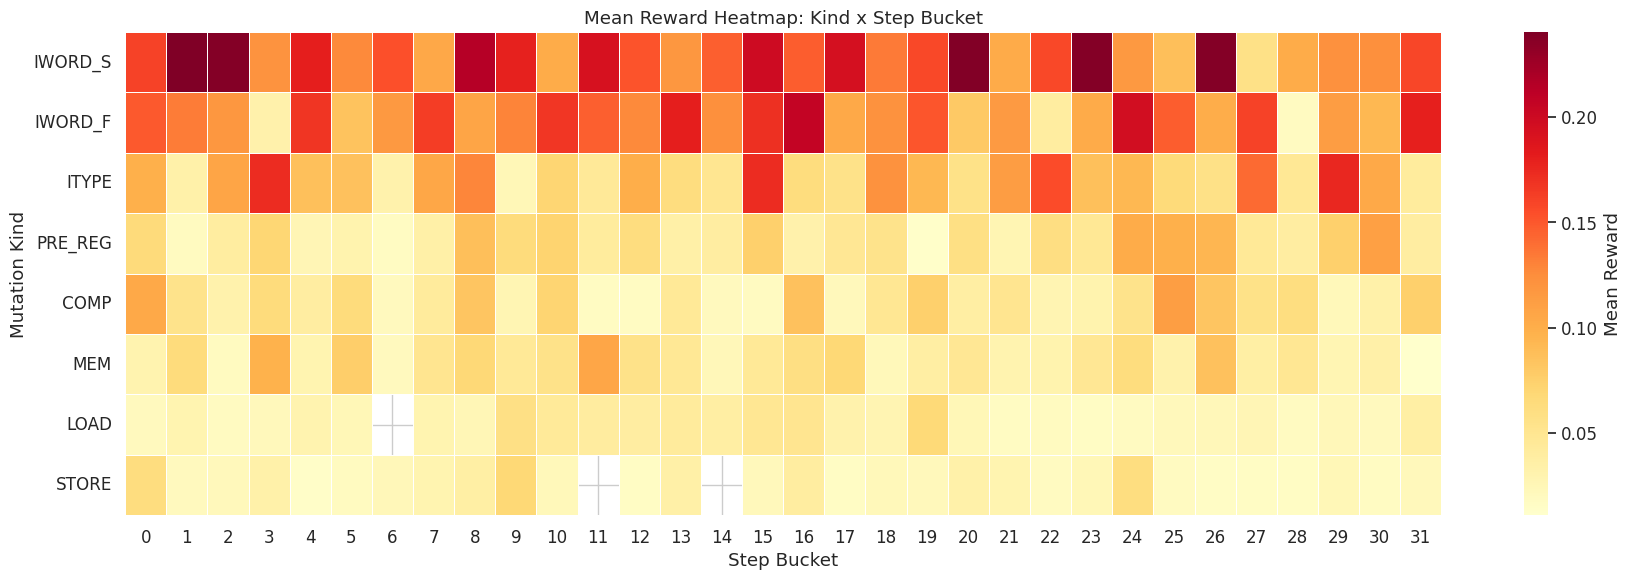

In [11]:
B = 123  # steps per bucket for this campaign
df['bucket'] = df['step'] // B

pivot_reward = df.pivot_table(values='reward', index='kind_short', columns='bucket', aggfunc='mean')
pivot_reward = pivot_reward.reindex(KIND_ORDER)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(pivot_reward, ax=ax, cmap='YlOrRd', annot=False, fmt='.2f',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Mean Reward'})
ax.set_title('Mean Reward Heatmap: Kind x Step Bucket')
ax.set_xlabel('Step Bucket')
ax.set_ylabel('Mutation Kind')

plt.tight_layout()
plt.show()

---
## 10. Arm-Level Selection Analysis

The reward heatmap above showed which arms *have* high reward. But does the bandit
actually *select* high-reward arms more often? This is the key test of whether
learning is occurring at the arm level.

Three analyses:
1. **Selection count heatmap** — compare with the reward heatmap to see if hot spots align
2. **Reward vs selection count** — is there a positive correlation?
3. **Second-half selection fraction** — are high-reward arms selected proportionally more
   in the second half (after the bandit has gathered data)?

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Selection count heatmap
pivot_count = df.pivot_table(values='reward', index='kind_short', columns='bucket', aggfunc='count')
pivot_count = pivot_count.reindex(KIND_ORDER)
sns.heatmap(pivot_count, ax=axes[0], cmap='Blues', annot=False,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Count'})
axes[0].set_title('Selection Count per Arm')
axes[0].set_xlabel('Step Bucket')
axes[0].set_ylabel('Mutation Kind')

# 2. Arm mean reward vs selection count
arm_stats = df.groupby(['kind_short', 'bucket']).agg(
    mean_reward=('reward', 'mean'),
    count=('reward', 'count')
).reset_index()
axes[1].scatter(arm_stats['mean_reward'], arm_stats['count'], alpha=0.5, s=25, c='#2c3e50')
z = np.polyfit(arm_stats['mean_reward'], arm_stats['count'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, arm_stats['mean_reward'].max() * 1.05, 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (slope={z[0]:.1f})')
r_corr = np.corrcoef(arm_stats['mean_reward'], arm_stats['count'])[0, 1]
axes[1].set_title(f'Arm Reward vs Selection Count (r = {r_corr:.3f})')
axes[1].set_xlabel('Mean Reward')
axes[1].set_ylabel('Times Selected')
axes[1].legend()

# 3. Second-half selection fraction vs reward
mid = len(df) // 2
first_half = df.iloc[:mid]
second_half = df.iloc[mid:]
first_arm = first_half.groupby(['kind_short', 'bucket']).size().rename('first')
second_arm = second_half.groupby(['kind_short', 'bucket']).size().rename('second')
arm_halves = pd.concat([first_arm, second_arm], axis=1).fillna(0)
arm_halves['total'] = arm_halves['first'] + arm_halves['second']
arm_halves['second_frac'] = arm_halves['second'] / arm_halves['total']
arm_halves = arm_halves[arm_halves['total'] >= 2].reset_index()
arm_reward = df.groupby(['kind_short', 'bucket'])['reward'].mean().rename('mean_reward').reset_index()
arm_halves = arm_halves.merge(arm_reward, on=['kind_short', 'bucket'])

axes[2].scatter(arm_halves['mean_reward'], arm_halves['second_frac'],
                alpha=0.5, s=25, c='#2c3e50')
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Balanced (50%)')
if len(arm_halves) > 1:
    z2 = np.polyfit(arm_halves['mean_reward'], arm_halves['second_frac'], 1)
    p2 = np.poly1d(z2)
    x2 = np.linspace(0, arm_halves['mean_reward'].max() * 1.05, 100)
    axes[2].plot(x2, p2(x2), 'r--', linewidth=2, label=f'Trend (slope={z2[0]:.2f})')
    r2 = np.corrcoef(arm_halves['mean_reward'], arm_halves['second_frac'])[0, 1]
    axes[2].set_title(f'Reward vs 2nd-Half Fraction (r = {r2:.3f})')
else:
    r2 = float('nan')
    axes[2].set_title('Reward vs 2nd-Half Selection Fraction')
axes[2].set_xlabel('Arm Mean Reward')
axes[2].set_ylabel('Fraction Selected in 2nd Half')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'\nArm-level selection analysis:')
print(f'  Total arms sampled: {len(arm_stats)}')
print(f'  Mean samples/arm: {arm_stats["count"].mean():.1f}')
print(f'  Reward-count correlation (Pearson r): {r_corr:.3f}')
if len(arm_halves) > 1:
    print(f'  Arms with >=2 samples (for half analysis): {len(arm_halves)}')
    print(f'  Reward-2ndHalf correlation (Pearson r): {r2:.3f}')
above_median = arm_halves[arm_halves['mean_reward'] >= arm_halves['mean_reward'].median()]
below_median = arm_halves[arm_halves['mean_reward'] < arm_halves['mean_reward'].median()]
print(f'  High-reward arms avg 2nd-half frac: {above_median["second_frac"].mean():.3f}')
print(f'  Low-reward arms avg 2nd-half frac: {below_median["second_frac"].mean():.3f}')

---
## 11. Summary & What's Left to Be Seen

### What we can conclude from this campaign:

1. **The reward function differentiates kinds**: 5x spread between best (IWORD_S: 0.154) and worst (STORE: 0.029)
2. **Z events are the strongest stable signal**: 10.5% rate, 4.3x reward multiplier, only from instruction-word mutations
3. **The reward landscape has strong arm-level structure**: 16x spread in mean reward across arms, meaning there are productive arms for the bandit to exploit
4. **Novelty decays but doesn't collapse**: reward floor ~0.055, driven by F_rare + Z
5. **Cascades are correctly suppressed**: 15 cascade runs get near-zero reward

### What is still left to be seen:

1. **Arm-level exploitation**: The arm-level selection analysis (Section 10) shows whether
   the bandit is preferentially selecting high-reward arms. With ~3.7 samples/arm, the
   bandit is still in exploration. A 2000+ mutation campaign would give enough data to
   see clear exploitation.

2. **Kind-level exploitation**: Kind-level selection is flat across all 10 phases — the
   bandit has not concentrated on high-reward kinds yet. This is a coarse aggregation
   that hides arm-level behavior, but longer campaigns are needed to confirm.

3. **Bandit vs Uniform comparison**: We haven't run a uniform-random campaign at the same
   scale. Does the bandit discover more Z events, reach more failure context_ids, or achieve
   higher cumulative reward than uniform? This is Phase II.5.

4. **Weight tuning impact**: Would increasing a_Z from 1.0 to 2.0 cause the bandit to
   concentrate harder on Z-producing instruction-word mutations? Phase II.5 A/B test.

5. **Longer campaign saturation**: At what point does the failure context space fully
   saturate? F_new rate is still 6-7% at run 946 — there's more to discover.

6. **Global constraint instrumentation**: All Z events fail at verification stages beyond
   our local constraint instrumentation. Adding global constraint tracking would reveal
   which specific checks are catching these mutations.

---
# Appendix A: Algorithm Specification

## A.1 Coverage Key Definitions

The coverage system tracks two types of coverage:

**Touch coverage** measures which constraints are *evaluated* (active) during witness generation. Each constraint evaluation passes through the `eqz` choke point in the prover. The touch key is:

$$\text{TouchKey} := (\texttt{constraint\_loc},\; \texttt{major},\; \texttt{minor})$$

hashed into a fixed bitmap of size $M = 65536$ using FNV-1a. The bitmap entry $B_t[i] \in \{0, \ldots, 255\}$ is a saturating counter.

**Failure coverage** measures which constraints *fail* (non-zero residual). The failure key is the same triple, stored as an exact set (no hashing):

$$\text{FailKey} := (\texttt{constraint\_loc},\; \texttt{major},\; \texttt{minor})$$

---

## A.2 Per-Run Observations

Each mutation run $t$ produces:

$$U_t = \{ i \in [0, M) : B_t[i] > 0 \} \quad \text{(touched bitmap indices)}$$

$$F_t = \{ (\text{loc}(f),\, \text{major}(f),\, \text{minor}(f)) : f \in \mathcal{L}_t \} \quad \text{(distinct failure contexts)}$$

$$n_{\text{fail}} = |\mathcal{L}_t| \quad \text{(raw failure instances)}, \qquad d_{\text{fail}} = |F_t| \quad \text{(distinct)}, \qquad r_{\text{rep}} = \max(0,\; n_{\text{fail}} - d_{\text{fail}}) \quad \text{(cascade repeats)}$$

---

## A.3 Global State

The campaign maintains cumulative state updated after each valid (non-crash) run:

$$G[i] \in \{0,1\} \quad \text{(touch seen indicator: } G[i]=1 \iff \exists\, t' : i \in U_{t'}\text{)}$$

$$f_T[i] \in \mathbb{N} \quad \text{(touch run-frequency: number of valid runs where } i \in U_{t'}\text{)}$$

$$f_F[c] \in \mathbb{N} \quad \text{(failure context run-frequency: number of valid runs where } c \in F_{t'}\text{, per-run-per-context)}$$

---

## A.4 Reward Function

### Novelty counts (computed **before** updating global state):

$$\Delta_T = |\{ i \in U_t : G[i] = 0 \}| \qquad \Delta_F = |\{ c \in F_t : f_F[c] = 0 \}|$$

### Component scores:

**Touch novelty:**
$$T_{\text{new}} = 1 - \exp\!\left(-\frac{\Delta_T}{\tau_T}\right)$$

**Touch rarity** (top-$K_T$ rarest touched buckets):
$$w_T(i) = \frac{1}{\sqrt{1 + f_T[i]}}, \qquad T_{\text{rare}} = \frac{1}{K_T} \sum_{i \in \text{TopK}_{K_T}(U_t)} w_T(i)$$

**Failure novelty:**
$$F_{\text{new}} = 1 - \exp\!\left(-\frac{\Delta_F}{\tau_{F,\text{new}}}\right)$$

**Failure rarity** (top-$K_F$ rarest failure contexts):
$$w_F(c) = \frac{1}{\sqrt{1 + f_F[c]}}, \qquad F_{\text{rare}} = \frac{1}{K_F} \sum_{c \in \text{TopK}_{K_F}(F_t)} w_F(c) \qquad \text{(0 if } |F_t|=0\text{)}$$

**Zero-local-fail indicator:**
$$Z = \mathbf{1}\!\left[\text{outcome} = \text{REJECTED} \;\wedge\; \text{proof\_generated} = \text{True} \;\wedge\; d_{\text{fail}} = 0\right]$$

### Execution quality (Q):

$$Q_{\text{dist}} = \exp\!\left(-\frac{d_{\text{fail}}}{\tau_d}\right), \qquad Q_{\text{rep}} = \begin{cases} 1 & r_{\text{rep}} \leq r_0 \\ \exp\!\left(-\frac{r_{\text{rep}} - r_0}{\tau_r}\right) & r_{\text{rep}} > r_0 \end{cases}$$

$$Q = \begin{cases} 0 & \text{if crash or missing bitmap} \\ Q_{\text{dist}} \cdot Q_{\text{rep}} & \text{otherwise} \end{cases}$$

### Final reward:

$$S = \frac{a_{T_n} T_{\text{new}} + a_{T_r} T_{\text{rare}} + a_{F_n} F_{\text{new}} + a_{F_r} F_{\text{rare}} + a_Z Z}{a_{T_n} + a_{T_r} + a_{F_n} + a_{F_r} + a_Z}$$

$$r_t = \min(1,\; Q \cdot S) \qquad \text{(override: } r_t = 1 \text{ if ACCEPTED)}$$

---

## A.5 Parameter Table

| Symbol | Value | Type | Description |
|--------|-------|------|-------------|
| $M$ | 65536 | HARD | Bitmap size |
| $\tau_T$ | calibrated (35-42) | CALIBRATE | Touch novelty scale (p75 of nonzero $\Delta_T$) |
| $\tau_d$ | calibrated (2.8-3.0) | CALIBRATE | Distinct-failure penalty scale (p75 of $d_{\text{fail}}$) |
| $K_T$ | calibrated (31) | CALIBRATE | Touch rarity top-K ($\lfloor 0.02 \cdot \text{median}(|U_t|)\rfloor$, clamped [16,64]) |
| $\tau_{F,\text{new}}$ | 2.0 | HARD | Failure novelty scale |
| $K_F$ | 2 | HARD | Failure rarity top-K |
| $r_0$ | 10 | HARD | Cascade threshold |
| $\tau_r$ | 25.0 | HARD | Cascade penalty slope |
| $a_{T_n}, a_{T_r}, a_{F_n}, a_{F_r}, a_Z$ | 1.0, 0.25, 1.0, 1.0, 1.0 | HARD | Component weights |

---

## A.6 End-to-End Discounted-UCB Bandit Algorithm

The complete algorithm that runs a coverage-guided fuzzing campaign:

---

**Algorithm: Coverage-Guided Discounted-UCB Fuzzing Campaign**

---

**Input:** Host binary, guest args, budget $N$, seed $s$, mutation kinds $\mathcal{K}$ (with $|\mathcal{K}|=8$)

**Parameters:** $\gamma$ (discount), $c$ (exploration), $n_{\min}$ (forced exploration), $\varepsilon = 10^{-6}$

---

**Phase 0 — Setup**

1. Run **inspection** $\to$ trace data (cycles, steps, transactions)
2. Capture **baseline** touch $\to$ bitmap $B_{\text{base}}$
3. Construct **arm universe**: $T \gets 1 + \max(\bigcup_k S_k)$, $B_{\text{count}} \gets \text{pow2\_clamp}(N / (|\mathcal{K}| \cdot 3),\, 16,\, 128)$, bucket size $B \gets \lceil T/B_{\text{count}} \rceil$
4. Arms: $\mathcal{A} = \{(k, b) : S_{k,b} \neq \emptyset\}$ where $S_{k,b} = \{s \in S_k : \lfloor s/B \rfloor = b\}$

**Phase 1 — Pilot Calibration** ($N_{\text{pilot}} = \max(30, \min(100, \lfloor N/20 \rfloor))$ runs)

5. **for** $p = 1, \ldots, N_{\text{pilot}}$ **do**
6. $\quad$ Select kind uniformly: $k \sim \text{Uniform}(\mathcal{K})$
7. $\quad$ Select step via zoned selector: $s \gets \text{ZonedSelect}(S_k)$
8. $\quad$ Execute mutation, collect $\text{PilotRunStats}$
9. Calibrate: $\tau_T, \tau_d, K_T, \gamma \gets \text{CalibrateFromPilot}(\text{stats}, N)$

**Phase 2 — Initialize**

10. Create CoverageState, seed from $B_{\text{base}}$: $\forall i,\, G[i] \gets \mathbf{1}[B_{\text{base}}[i] > 0],\; f_T[i] \gets G[i]$
11. Merge pilot touch into CoverageState
12. Initialize bandit: $\forall a \in \mathcal{A},\; N_a \gets 0,\; S_a \gets 0,\; t_a \gets 0$
13. Initialize step-level bandit: $\forall (k,s),\; N_{k,s} \gets 0,\; S_{k,s} \gets 0,\; t_{k,s} \gets 0$
14. $t \gets 0$

**Phase 3 — Main Bandit Loop** ($N - N_{\text{pilot}}$ rounds)

15. **for** $i = 1, \ldots, N - N_{\text{pilot}}$ **do**
16. $\quad t \gets t + 1$
17.
18. $\quad$ **— Arm-level selection —**
19. $\quad$ **for all** $a \in \mathcal{A}$ **do** $\quad$ *(lazy decay)*
20. $\quad\quad$ $N_a \gets \gamma^{t - t_a} N_a, \quad S_a \gets \gamma^{t - t_a} S_a, \quad t_a \gets t$
21. $\quad$ **if** $\exists\, a : N_a < n_{\min}$ **then**
22. $\quad\quad$ $a^* \gets \text{RandomChoice}(\{a : N_a < n_{\min}\})$ $\quad$ *(forced exploration)*
23. $\quad$ **else**
24. $\quad\quad$ $N_{\text{tot}} \gets \sum_{a \in \mathcal{A}} N_a$
25. $\quad\quad$ $a^* \gets \arg\max_{a \in \mathcal{A}} \left[ \frac{S_a}{\max(N_a, \varepsilon)} + c \sqrt{\frac{\log(1 + N_{\text{tot}})}{\max(N_a, \varepsilon)}} \right]$ $\quad$ *(UCB)*
26. $\quad$ Let $a^* = (k^*, b^*)$
27.
28. $\quad$ **— Step-level selection —**
29. $\quad$ **for all** $s \in S_{k^*, b^*}$ **do** $\quad$ *(lazy decay)*
30. $\quad\quad$ $N_{k^*,s} \gets \gamma^{t - t_{k^*,s}} N_{k^*,s}, \; \ldots, \; t_{k^*,s} \gets t$
31. $\quad$ **if** $\exists\, s : N_{k^*,s} < n_{\min}$ **then** forced exploration **else** UCB (same formula, $N_{\text{tot}}^{(k^*,b^*)}$ scoped to bucket)
32. $\quad$ Selected: $(k^*, s^*)$
33.
34. $\quad$ **— Execute and evaluate —**
35. $\quad$ Create mutation config for $(k^*, s^*)$, execute host $\to$ bitmap $B_t$, failures $\mathcal{L}_t$, exit code, outcome
36. $\quad$ Compute reward: $(r_t, \text{diag}) \gets \text{ComputeReward}(B_t, \mathcal{L}_t, \ldots, \text{CoverageState})$ $\quad$ *(reads state before this run)*
37.
38. $\quad$ **— Update bandit —**
39. $\quad$ $N_{a^*} \gets N_{a^*} + 1, \quad S_{a^*} \gets S_{a^*} + r_t, \quad t_{a^*} \gets t$
40. $\quad$ $N_{k^*,s^*} \gets N_{k^*,s^*} + 1, \quad S_{k^*,s^*} \gets S_{k^*,s^*} + r_t, \quad t_{k^*,s^*} \gets t$
41.
42. $\quad$ **— Update coverage state —** *(writes this run's data for next iteration)*
43. $\quad$ **if** valid run (not crash, bitmap present) **then**
44. $\quad\quad$ $\forall i \in U_t: G[i] \gets 1,\; f_T[i] \gets f_T[i] + 1$
45. $\quad\quad$ $\forall c \in F_t: f_F[c] \gets f_F[c] + 1$

---

**Output:** Campaign statistics, bandit arm rankings, coverage maps, Z-event log

In [12]:
print('=== CAMPAIGN SUMMARY ===')
print(f'Total: {len(runs)} runs ({len(pilot)} pilot + {len(bandit)} bandit)')
print(f'Outcomes: REJECTED={sum(1 for r in bandit if r.outcome=="REJECTED")}, '
      f'CRASH={sum(1 for r in bandit if r.outcome=="CRASH")}, '
      f'ACCEPTED={sum(1 for r in bandit if r.outcome=="ACCEPTED")}')
print(f'Mean reward: {df["reward"].mean():.4f} (std={df["reward"].std():.4f})')
print(f'Z events: {df["Z"].sum()} ({df["Z"].mean()*100:.1f}%)')
print(f'Z reward: {z_df["reward"].mean():.3f} vs non-Z: {df[df["Z"]==0]["reward"].mean():.3f}')
print(f'Distinct touched: 2439 (baseline 1599 + {2439-1599} new)')
print(f'Unique constraints: 29 families')

=== CAMPAIGN SUMMARY ===
Total: 996 runs (50 pilot + 946 bandit)
Outcomes: REJECTED=935, CRASH=11, ACCEPTED=0
Mean reward: 0.0742 (std=0.0774)
Z events: 99 (10.5%)
Z reward: 0.239 vs non-Z: 0.055
Distinct touched: 2439 (baseline 1599 + 840 new)
Unique constraints: 29 families
